In [ ]:
import pandas as pd
import numpy as np

In [ ]:
pip install vk_api pandas

In [ ]:
import vk_api
from datetime import datetime
from tqdm import tqdm
import time
import pandas as pd

token = 'XXXXXXXXX'

vk_session = vk_api.VkApi(token=token)
vk = vk_session.get_api()

# Выбрали группы из ВК, в которых сидят наши потенциальные клиенты
group_ids = [
    'singerbar.moscow',
    'karaokebarles',
    'fortepianokaraoke',
    'karaoke_moskow',
    'semenov_karaoke'
]





fields = (
    'sex,bdate,city,country,home_town,relation,'
    'occupation,career,universities,schools,personal,activities,'
    'interests,music,movies,tv,books,games,about,quotes,followers_count' #возьмем у них все парамеры что есть
)

def calculate_age(bdate):

    try:
        birthdate = datetime.strptime(bdate, '%d.%m.%Y')

        today = datetime.now()

        age = today.year - birthdate.year - ((today.month, today.day) < (birthdate.month, birthdate.day))
        return age

    except:
        return None

users_data = []


collected_ids = set()

for group_id in group_ids:
    offset = 0
    batch_size = 500
    group_info = vk.groups.getMembers(group_id=group_id)
    total_group_members = group_info['count']

    print("")
    print("Группа: ", group_id, ", подписчиков: ", total_group_members)


    while offset < total_group_members:

        members_batch = vk.groups.getMembers(group_id=group_id, offset=offset, count=batch_size)['items']

        offset += batch_size
        # Группы на одну тематику, поэтому хотим только уникальных человечков
        new_members = [m for m in members_batch if m not in collected_ids]

        user_info = vk.users.get(user_ids=new_members, fields=fields)
        for user in tqdm(user_info, desc=f"обработка айди {group_id}"):
            user_id = user['id']
            try:
                groups = vk.groups.get(user_id=user_id, extended=1, fields='name', count=1000)

                user_groups = [group['name'] for group in groups['items']]
            except:


                user_groups = []

            data = {
                'source_group': group_id,
                'id': user_id,
                'first_name': user.get('first_name'),
                'last_name': user.get('last_name'),
                'sex': 'Женский' if user.get('sex') == 1 else 'Мужской' if user.get('sex') == 2 else 'Не указан',
                'age': calculate_age(user.get('bdate', '')),
                'city': user.get('city', {}).get('title'),
                'country': user.get('country', {}).get('title'),
                'home_town': user.get('home_town'),
                'relation': user.get('relation'),
                'occupation': user.get('occupation', {}).get('name'),
                'career': '; '.join([job.get('company', '') for job in user.get('career', [])]),
                'universities': '; '.join([uni.get('name', '') for uni in user.get('universities', [])]),
                'schools': '; '.join([school.get('name', '') for school in user.get('schools', [])]),
                'activities': user.get('activities'),
                'interests': user.get('interests'),
                'music': user.get('music'),
                'movies': user.get('movies'),
                'tv': user.get('tv'),
                'books': user.get('books'),
                'games': user.get('games'),
                'about': user.get('about'),
                'quotes': user.get('quotes'),
                'followers_count': user.get('followers_count'),
                'groups': '; '.join(user_groups[:20])
            }

            users_data.append(data)
            collected_ids.add(user_id)
            time.sleep(0.35)
# чистим дубли
df = pd.DataFrame(users_data).drop_duplicates(subset=['id'])

# Finally)))
df.to_csv('karaoke_1draft.csv', index=False, encoding='utf-8-sig')



Группа:  singerbar.moscow , подписчиков:  2045


обработка айди singerbar.moscow: 100%|██████████| 45/45 [00:44<00:00,  1.01it/s]



Группа:  karaokebarles , подписчиков:  1419


обработка айди karaokebarles: 100%|██████████| 414/414 [07:01<00:00,  1.02s/it]



Группа:  fortepianokaraoke , подписчиков:  572


обработка айди fortepianokaraoke: 100%|██████████| 69/69 [01:15<00:00,  1.10s/it]



Группа:  karaoke_moskow , подписчиков:  376


обработка айди karaoke_moskow: 100%|██████████| 371/371 [12:36<00:00,  2.04s/it]



Группа:  semenov_karaoke , подписчиков:  490


обработка айди semenov_karaoke: 100%|██████████| 460/460 [07:44<00:00,  1.01s/it]


In [ ]:
df.shape

(4821, 25)

In [ ]:
df.head(5)

,source_group,id,first_name,last_name,sex,age,city,country,home_town,relation,...,interests,music,movies,tv,books,games,about,quotes,followers_count,groups
0,singerbar.moscow,7297,Lera,Grigoryeva,Женский,NaN,Moscow,None,None,NaN,...,None,None,None,None,None,None,None,None,NaN,
1,singerbar.moscow,167662,Anton,Bulavkin,Мужской,NaN,Moscow,None,None,NaN,...,None,None,None,None,None,None,None,None,2941.0,НОВАЯ МУЗЫКА — Популярные Песни; VK Музыка; КИ...
2,singerbar.moscow,319200,Tatyana,Boyko,Женский,NaN,None,None,Москва,4.0,...,"Мистика, психология, философия, буддизм, Тибет...","Witch House, Hardcore, alternative rock, alter...","Butterfly effect, Трасса 60, Готика, Игры разу...",,"Макс Фрай ""Чужак"", ""Автостопом по галактике"", ...",,"Бывают моменты, когда ты готов отдать все ради...","Счастье – верить, когда не верится,\nИ дышать ...",2306.0,
3,singerbar.moscow,446819,Alexy,Sledopyt,Мужской,NaN,Moscow,None,None,NaN,...,None,None,None,None,None,None,None,None,119.0,
4,singerbar.moscow,461487,Oleg,Rezepov,Мужской,NaN,Moscow,None,None,NaN,...,None,None,None,None,None,None,None,None,568.0,


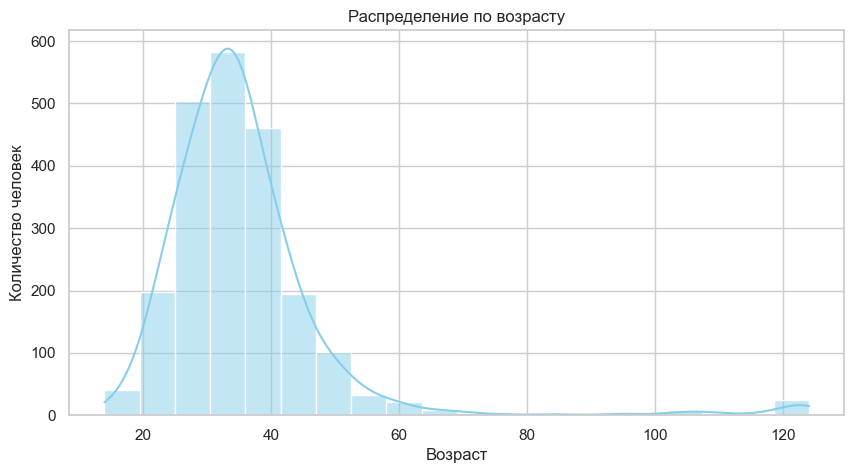

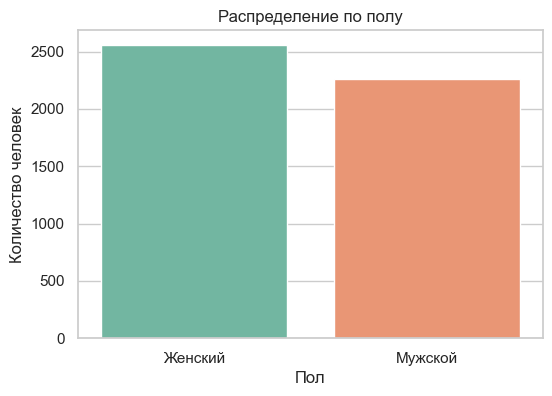

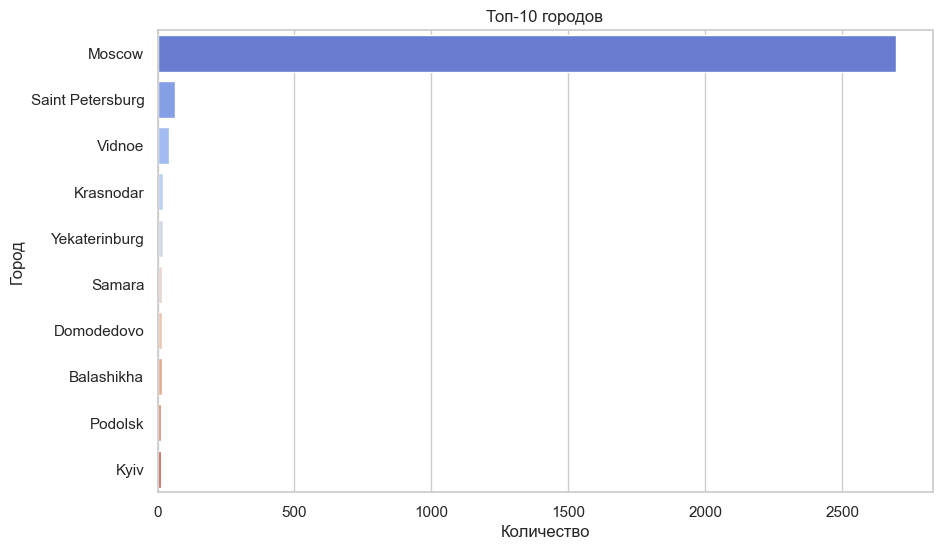

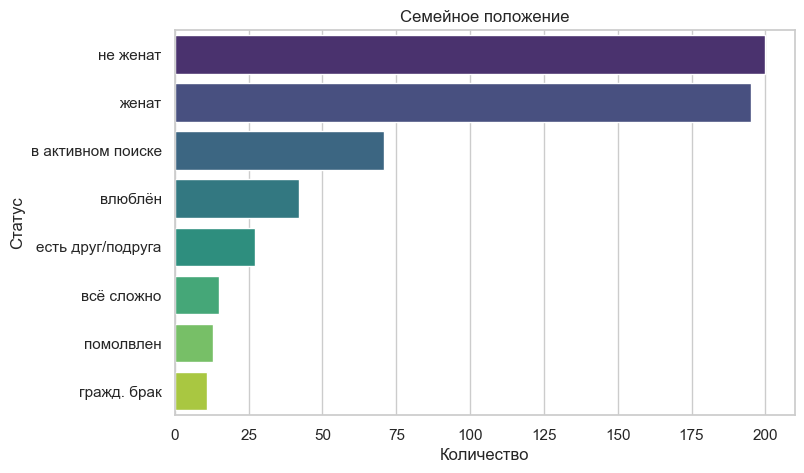

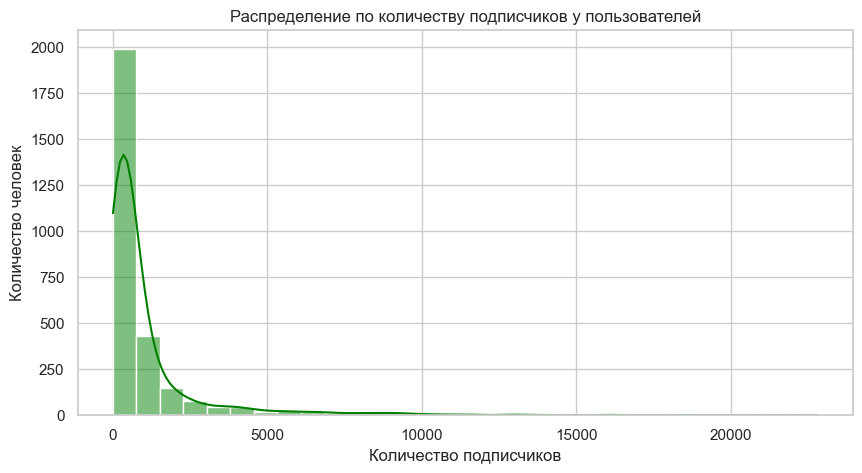

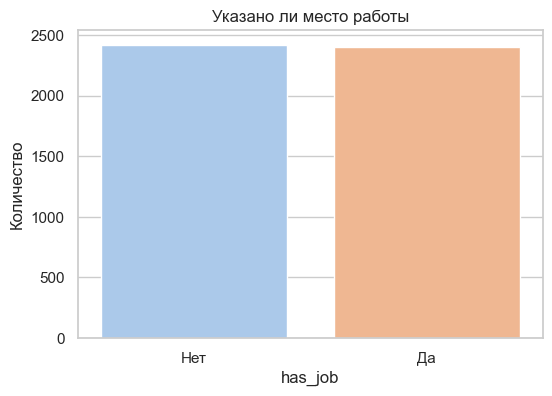

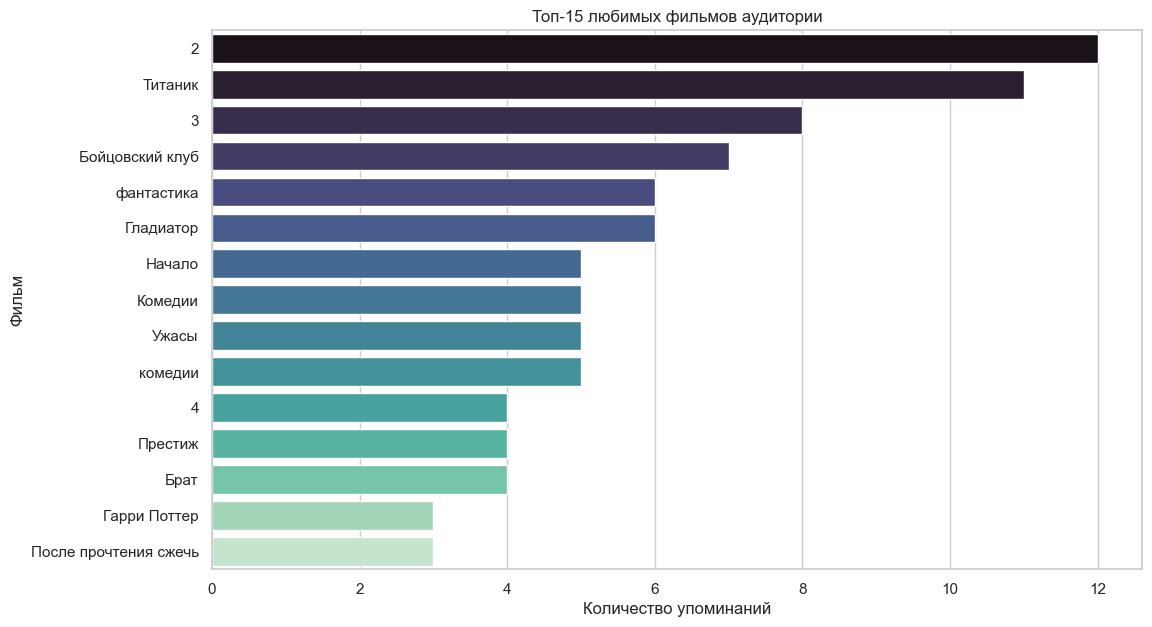

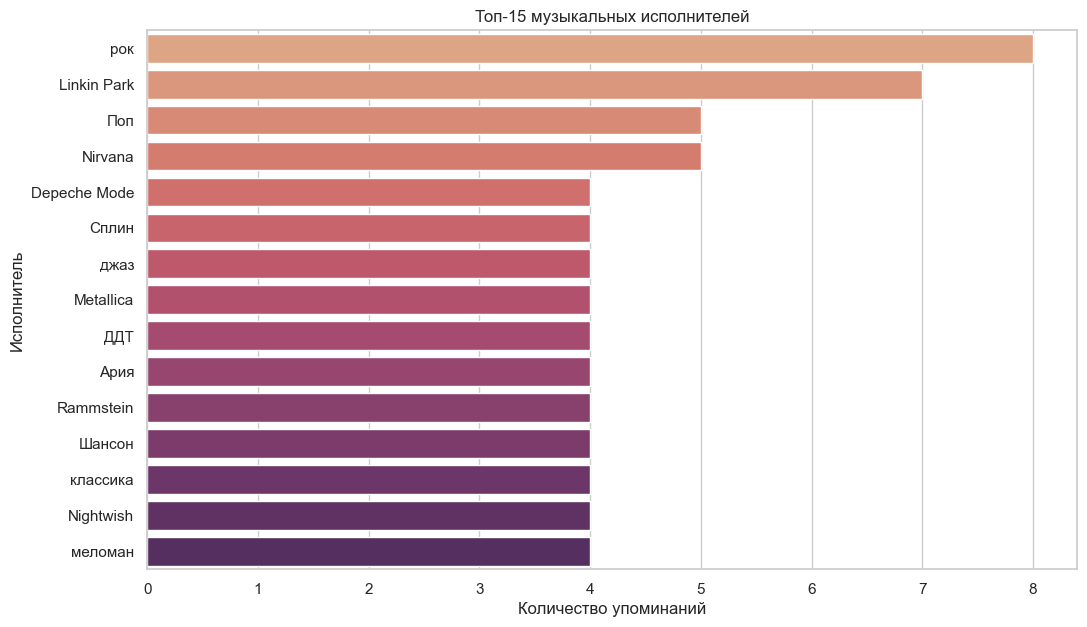

/Users/coverkincel/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129655 (\U0001fa77) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/coverkincel/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


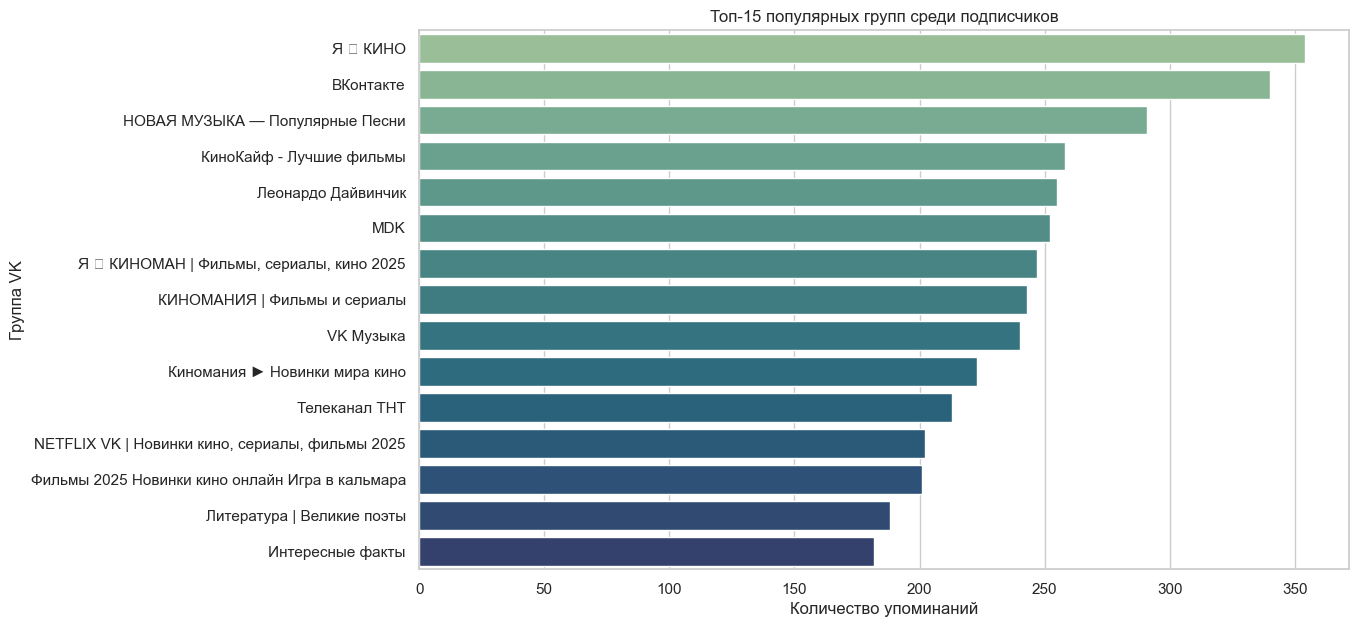

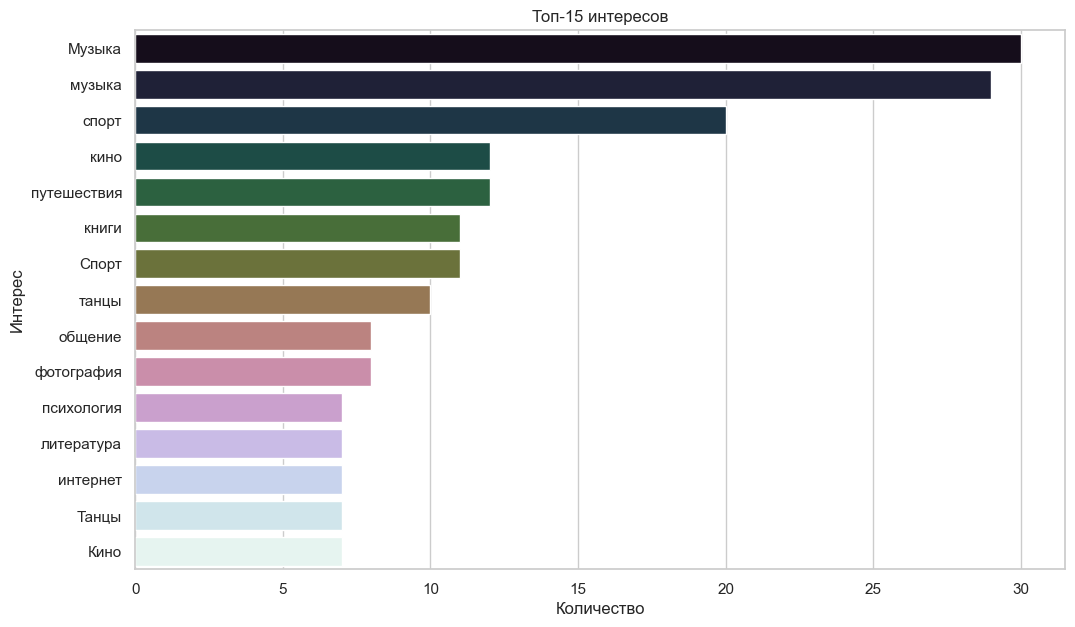

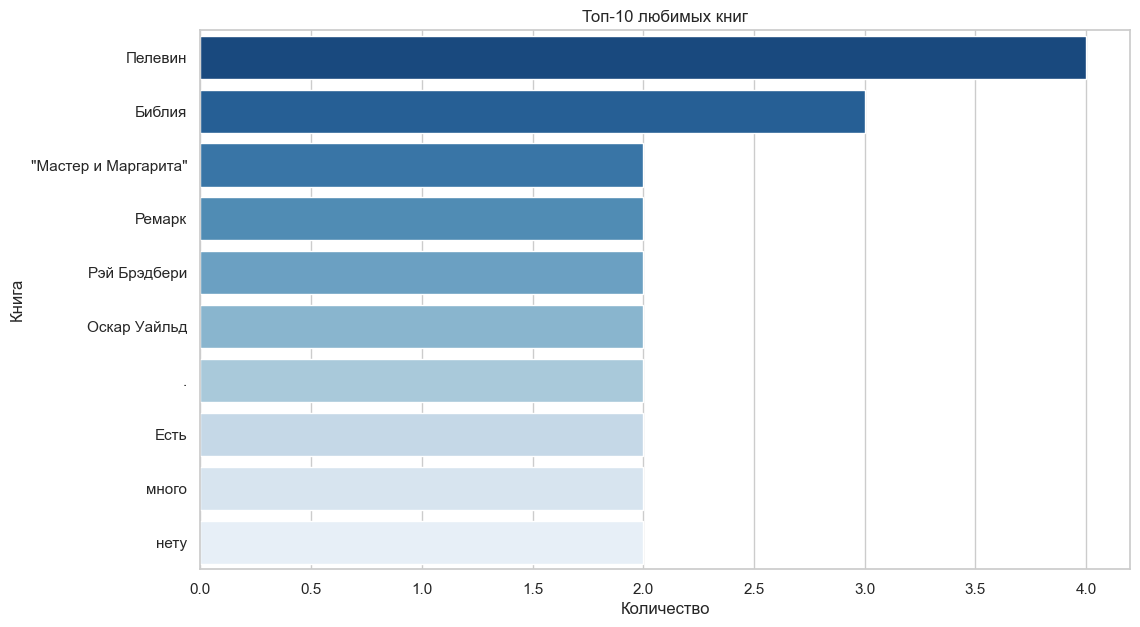

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

pd.set_option('display.max_columns', None)

sns.set(style='whitegrid')


df = pd.read_csv('karaoke_1draft.csv')

# Посмотрим возраст и пол


plt.figure(figsize=(10,5))

sns.histplot(df['age'].dropna(), bins=20, kde=True, color='skyblue')

plt.title('Распределение по возрасту')
plt.xlabel('Возраст')
plt.ylabel('Количество человек')
plt.show()


# Распределение по полу
plt.figure(figsize=(10,5))
df_sex_filtered = df[df['sex'].isin(['Мужской', 'Женский'])]
sns.countplot(data=df_sex_filtered, x='sex', palette='Set2')
plt.title('Распределение по полу')
plt.xlabel('Пол')
plt.ylabel('Количество человек')
plt.show()


# Города (Потом бы хорошо оставить только Москву)
top_cities = df['city'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_cities.values, y=top_cities.index, palette='coolwarm')

plt.title('Топ-10 городов')
plt.xlabel('Количество')
plt.ylabel('Город')
plt.show()

# замужем \нет (потом может поможет нам для рекламы)
relation_dict = {1:'не женат',2:'есть друг/подруга',3:'помолвлен',4:'женат',5:'всё сложно',6:'в активном поиске',7:'влюблён',8:'гражд. брак'}
df['relation_status'] = df['relation'].map(relation_dict)


plt.figure(figsize=(10,5))

sns.countplot(y='relation_status', data=df, order=df['relation_status'].value_counts().index, palette='viridis')


plt.title('Семейное положение')
plt.xlabel('Количество')
plt.ylabel('Статус')
plt.show()

# Сколько у них подписчиков (раз есть инфа - пользуемся)
plt.figure(figsize=(10,5))

sns.histplot(df['followers_count'].dropna(), bins=30, kde=True, color='green')


plt.title('Распределение по количеству подписчиков у пользователей')
plt.xlabel('Количество подписчиков')
plt.ylabel('Количество человек')
plt.show()

# Работа
df['has_job'] = df['occupation'].notnull()
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='has_job', palette='pastel')

plt.title('Указано ли место работы')
plt.xticks([0,1], ['Нет','Да'])
plt.ylabel('Количество')
plt.show()


import re

# любимые фильмы
def get_top_movies(series, top_n=15):
    items = series.dropna().apply(lambda x: re.split(r'[;,\.]', x))
    flat_items = [item.strip() for sublist in items for item in sublist if item.strip()]
    return pd.DataFrame(Counter(flat_items).most_common(top_n), columns=['Название', 'Количество'])
def get_top_items(series, delimiters, top_n=15):
    pattern = '|'.join(map(re.escape, delimiters))
    items = series.dropna().apply(lambda x: re.split(pattern, x))
    flat_items = [item.strip() for sublist in items for item in sublist if item.strip()]
    return pd.DataFrame(Counter(flat_items).most_common(top_n), columns=['Название', 'Количество'])

# Топ-15 фильмов
top_movies = get_top_movies(df['movies'], top_n=15)

plt.figure(figsize=(12,7))
sns.barplot(x='Количество', y='Название', data=top_movies, palette='mako')
plt.title('Топ-15 любимых фильмов аудитории')
plt.xlabel('Количество упоминаний')
plt.ylabel('Фильм')
plt.show()
# любимая музыка
top_music = get_top_items(df['music'], ',', top_n=15)
plt.figure(figsize=(12,7))
sns.barplot(x='Количество', y='Название', data=top_music, palette='flare')
plt.title('Топ-15 музыкальных исполнителей')
plt.xlabel('Количество упоминаний')
plt.ylabel('Исполнитель')
plt.show()

# их группы
top_groups = get_top_items(df['groups'], ';', top_n=15)

plt.figure(figsize=(12,7))

sns.barplot(x='Количество', y='Название', data=top_groups, palette='crest')
plt.title('Топ-15 популярных групп среди подписчиков')
plt.xlabel('Количество упоминаний')
plt.ylabel('Группа VK')
plt.show()

#интересы
top_interests = get_top_items(df['interests'], ',', top_n=15)
plt.figure(figsize=(12,7))
sns.barplot(x='Количество', y='Название', data=top_interests, palette='cubehelix')
plt.title('Топ-15 интересов')
plt.xlabel('Количество')
plt.ylabel('Интерес')
plt.show()

#книги
top_books = get_top_items(df['books'], ',', top_n=10)
plt.figure(figsize=(12,7))
sns.barplot(x='Количество', y='Название', data=top_books, palette='Blues_r')
plt.title('Топ-10 любимых книг')
plt.xlabel('Количество')
plt.ylabel('Книга')
plt.show()


In [ ]:
df.head(5)

,source_group,id,first_name,last_name,sex,age,city,country,home_town,relation,occupation,career,universities,schools,activities,interests,music,movies,tv,books,games,about,quotes,followers_count,groups,relation_status,has_job
0,singerbar.moscow,7297,Lera,Grigoryeva,Женский,NaN,Moscow,NaN,NaN,NaN,Inditex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
1,singerbar.moscow,167662,Anton,Bulavkin,Мужской,NaN,Moscow,NaN,NaN,NaN,"СПбГЭУ (ранее ФИНЭК, ИНЖЭКОН, СПбГУСЭ)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2941.0,НОВАЯ МУЗЫКА — Популярные Песни; VK Музыка; КИ...,NaN,True
2,singerbar.moscow,319200,Tatyana,Boyko,Женский,NaN,NaN,NaN,Москва,4.0,Тайника,NaN,МУ Туро,Школа № 53,NaN,"Мистика, психология, философия, буддизм, Тибет...","Witch House, Hardcore, alternative rock, alter...","Butterfly effect, Трасса 60, Готика, Игры разу...",NaN,"Макс Фрай ""Чужак"", ""Автостопом по галактике"", ...",NaN,"Бывают моменты, когда ты готов отдать все ради...","Счастье – верить, когда не верится,\nИ дышать ...",2306.0,NaN,женат,True
3,singerbar.moscow,446819,Alexy,Sledopyt,Мужской,NaN,Moscow,NaN,NaN,NaN,министерство добрых дел,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119.0,NaN,NaN,True
4,singerbar.moscow,461487,Oleg,Rezepov,Мужской,NaN,Moscow,NaN,NaN,NaN,РСХБ.цифра,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,568.0,NaN,NaN,True


In [ ]:
pip install requests


Note: you may need to restart the kernel to use updated packages.


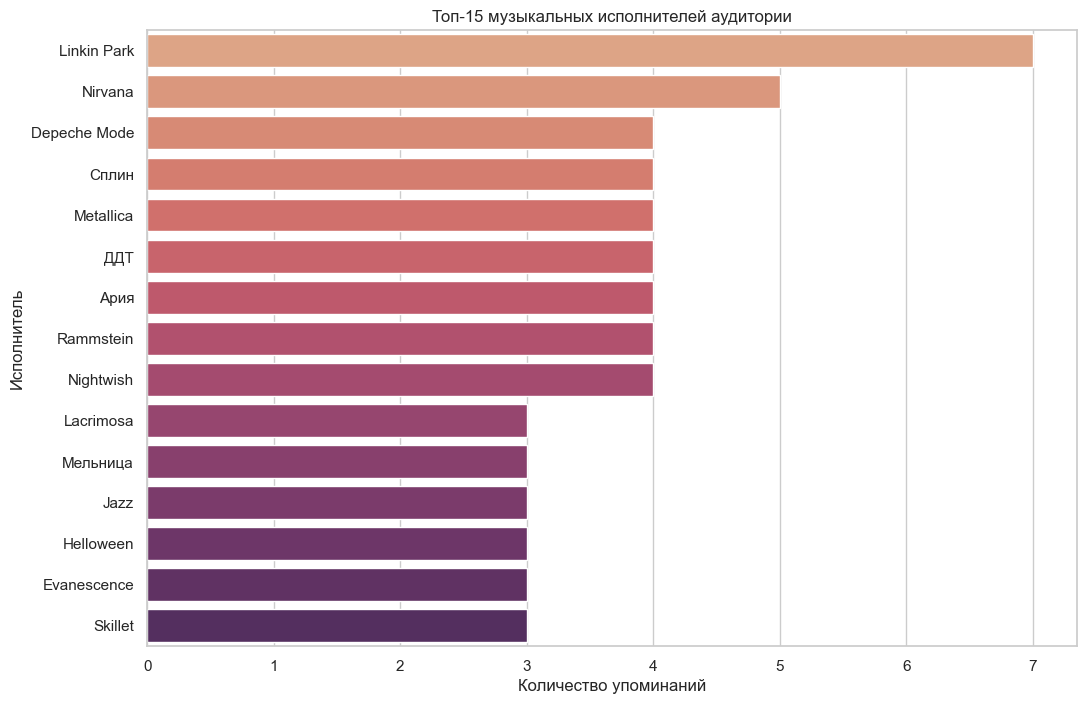

100%|██████████| 22/22 [00:06<00:00,  3.66it/s]


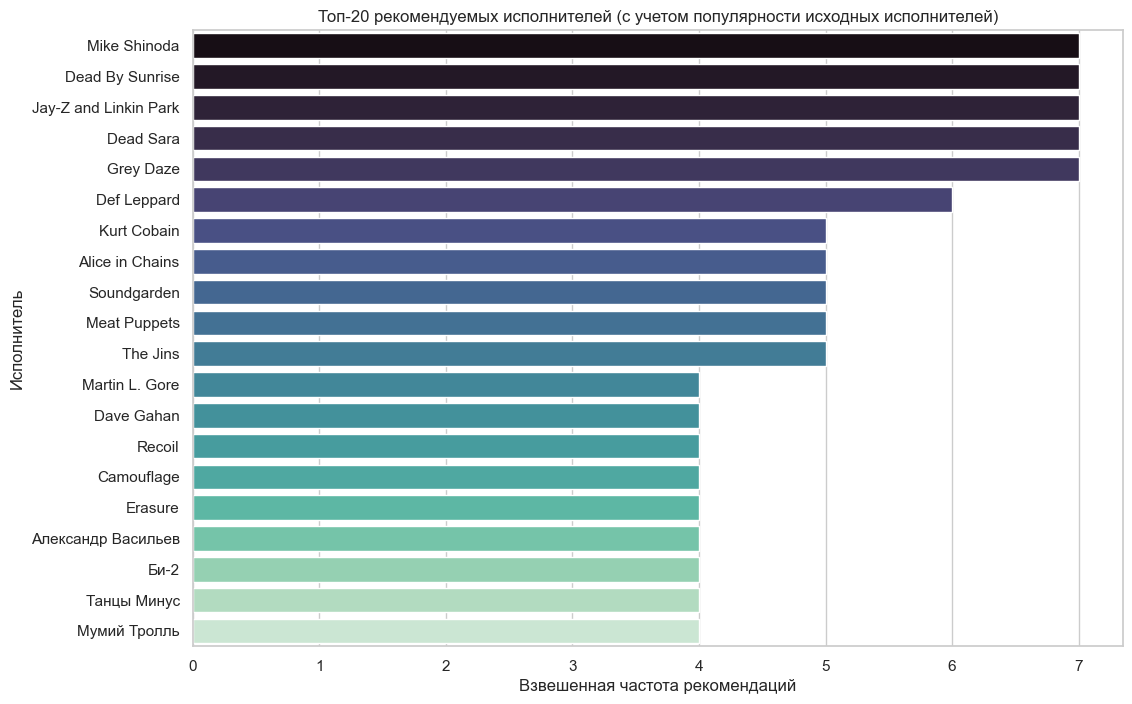

100%|██████████| 15/15 [00:04<00:00,  3.67it/s]

Итоговая аналитика (популярные исполнители и рекомендации):


,Исполнитель,Количество,Похожие исполнители
0,Linkin Park,7,"Mike Shinoda, Dead By Sunrise, Jay-Z and Linki..."
1,Nirvana,5,"Kurt Cobain, Alice in Chains, Soundgarden, Mea..."
2,Depeche Mode,4,"Martin L. Gore, Dave Gahan, Recoil, Camouflage..."
3,Сплин,4,"Александр Васильев, Би-2, Танцы Минус, Мумий Т..."
4,Metallica,4,"Megadeth, Pantera, Slayer, Anthrax, Iron Maiden"
5,ДДТ,4,"Юрий Шевчук, Чайф, Машина времени, Чиж & Co, С..."
6,Ария,4,"Кипелов, Валерий Кипелов, Сергей Маврин, Серге..."
7,Rammstein,4,"Lindemann, Till Lindemann, Emigrate, Eisbreche..."
8,Nightwish,4,"Epica, Tarja, Within Temptation, Delain, Xandria"
9,Lacrimosa,3,"Snakeskin, Sopor Aeternus & The Ensemble of Sh..."


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import requests
from tqdm import tqdm
import re

pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

df = pd.read_csv('karaoke_1draft.csv')

def get_top_items(series, delimiters, top_n=30):
    pattern = '|'.join(map(re.escape, delimiters))
    items = series.dropna().apply(lambda x: re.split(pattern, x))

    flat_items = [item.strip() for sublist in items for item in sublist if item.strip()]
    return pd.DataFrame(Counter(flat_items).most_common(top_n), columns=['Исполнитель', 'Количество'])
exclude_general = ['рок', 'джаз', 'поп', 'шансон', 'классика', 'меломан', 'любая', 'всё', 'разная', 'разное']

top_music = get_top_items(df['music'], [','], top_n=30)
top_music = top_music[~top_music['Исполнитель'].str.lower().isin(exclude_general)]

plt.figure(figsize=(12, 8))
sns.barplot(x='Количество', y='Исполнитель', data=top_music.head(15), palette='flare')
plt.title('Топ-15 музыкальных исполнителей аудитории')
plt.xlabel('Количество упоминаний')
plt.ylabel('Исполнитель')
plt.show()

API_KEY = 'ХХХХХХХХХ'

def get_similar_artists(artist_name, limit=5):
    url = f"http://ws.audioscrobbler.com/2.0/?method=artist.getsimilar&artist={artist_name}&api_key={API_KEY}&format=json&limit={limit}"
    response = requests.get(url).json()
    if 'similarartists' in response and 'artist' in response['similarartists']:
        return [a['name'] for a in response['similarartists']['artist']]
    return []

weighted_recommendations = Counter()

for idx, row in tqdm(top_music.iterrows(), total=top_music.shape[0]):
    artist = row['Исполнитель']
    weight = row['Количество']
    similar_artists = get_similar_artists(artist)

    for similar_artist in similar_artists:
        weighted_recommendations[similar_artist] += weight

recommend_weighted = pd.DataFrame(
    weighted_recommendations.most_common(20),
    columns=['Исполнитель', 'Взвешенная частота рекомендаций']
)

plt.figure(figsize=(12,8))
sns.barplot(x='Взвешенная частота рекомендаций', y='Исполнитель', data=recommend_weighted, palette='mako')
plt.title('Топ-20 рекомендуемых исполнителей (с учетом популярности исходных исполнителей)')
plt.xlabel('Взвешенная частота рекомендаций')
plt.ylabel('Исполнитель')
plt.show()

recommendations = pd.DataFrame([
    {'Исполнитель': artist, 'Похожие исполнители': ', '.join(get_similar_artists(artist))}
    for artist in tqdm(top_music['Исполнитель'].head(15))
])

final = top_music.merge(
    recommendations,
    on='Исполнитель',
    how='left'
).head(15)

display(final)